# Analysis Notebook

# Setup

In [ ]:
#| label: setup
#| include: false

options(warn = -1)

packages <- c("multcomp","DT","car","glmmTMB","AICcmodavg", "ggeffects","DHARMa", "brms", "emmeans", "lme4","lmerTest","vegan","ggnewscale","multcompView","patchwork","janitor","lubridate","stringr","tidyverse","dplyr","ggplot2","readxl","writexl","readr")

# Load packages if not already installed
quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

invisible(lapply(packages, quiet_load))

exc_file_dir <- "data/raw/NCE_data.xlsx"
der_data_dir <- "data/derived"
out_dir      <- "outputs"

# Read sheets from raw xlsx
df_NCE_raw <- readxl::read_excel(exc_file_dir, sheet = "NCE_exp")
df_Feeding_raw <- readxl::read_excel(exc_file_dir, sheet = "Feeding")

# Save as csv to derived/
write.csv(df_NCE_raw,     file.path(der_data_dir, "NCE_exp.csv"),  row.names = FALSE)
write.csv(df_Feeding_raw, file.path(der_data_dir, "Feeding.csv"),  row.names = FALSE)

df_NCE_raw     <- read.csv(file.path(der_data_dir, "NCE_exp.csv"))
df_Feeding_raw <- read.csv(file.path(der_data_dir, "Feeding.csv"))

# Set base for plots
base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "sans", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3))
theme_set(base_theme_bw)

# Refuge experiment

## Build refuge dataframe

In [ ]:
#| label: build-df
#| include: false

df_NCE_raw <- df_NCE_raw %>%
  dplyr::select(-location_T180, -behaviour_T180)

# make into long format
koura_long <- df_NCE_raw %>%
  pivot_longer(
    cols = matches("^(location|behaviour)_"),
    names_to   = c(".value","time"),
    names_pattern = "(location|behaviour)_T?(\\d+)" ) %>%
  mutate(time = as.numeric(time))

koura_long <- koura_long %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

#Group all refuge used
koura_long_ref <- koura_long %>%
  mutate(
    location = case_when(
      location %in% c("floor", "wall", "barrier") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_))

koura_long_ref <- koura_long_ref %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

## Refuge table

In [ ]:
#| label: tbl-s1-refuge-prop
#| include: true
#| tbl-cap: "Proportion of kōura observations recorded in refuge across experimental treatments (catfish, eel, control), light conditions (light, dark), and periods (before, during, and after predator exposure). Combined rows summarise across all levels of a given factor. Values represent the proportion of total observations where kōura were located in the refuge."

prop_refuge_light_treat <- koura_long_ref %>%
  dplyr::group_by(light, treatment, period) %>%
  dplyr::summarise(
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop") %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
         light     = factor(light,     levels = c("light", "dark"))) %>%
  arrange(light, treatment, period)

prop_refuge_treat <- koura_long_ref %>%
  dplyr::group_by(treatment, period) %>%
  dplyr::summarise(light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_light <- koura_long_ref %>%
  dplyr::group_by(light, period) %>%
  dplyr::summarise(treatment = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")%>%
  mutate(light     = factor(light,     levels = c("light", "dark"))) %>%
  arrange(light, treatment, period)

prop_refuge_per <- koura_long_ref %>%
  dplyr::group_by(period) %>%
  dplyr::summarise(treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_comb <- koura_long_ref %>%
  dplyr::summarise(period = "combined",
    treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

refuge_table <- dplyr::bind_rows(prop_refuge_light_treat, prop_refuge_treat,prop_refuge_light, prop_refuge_per, prop_refuge_comb) %>%
  mutate_if(is.numeric, round, digits = 2)

get_prop <- function(l, t, p) {
  refuge_table %>% 
    filter(light == l, treatment == t, period == p) %>% 
    pull(prop_refuge) %>% 
    `*`(100) %>% 
    paste0(round(., 1), "%")  # rounds to 1 decimal place and adds '%'
}

write.csv(refuge_table, file = file.path(out_dir, "refuge_table.csv"), row.names = FALSE)

if (knitr::is_html_output()) {
  datatable(
    refuge_table,
    filter = "top",
    options = list(
      pageLength = 37,
      dom = 'Bfrtip',
      buttons = c('csv', 'excel'),
      columnDefs = list(list(className = 'dt-center', targets = "_all"))
    ),
    extensions = 'Buttons',
    rownames = FALSE,
    colnames = c("Light", "Treatment", "Period", "N total", "N refuge", "Proportion in refuge")
  ) |>
    formatRound(columns = "prop_refuge", digits = 2) |>
    formatStyle(
      "prop_refuge",
      background = styleColorBar(range(refuge_table$prop_refuge), "lightblue"),
      backgroundSize = "100% 90%",
      backgroundRepeat = "no-repeat",
      backgroundPosition = "center"
    )
} else {
  knitr::kable(refuge_table, digits = 2)
}

  light      treatment   period       n_total   n_refuge   prop_refuge
  ---------- ----------- ---------- --------- ---------- -------------
  light      catfish     before            66         34          0.52
  light      catfish     during            99         71          0.72
  light      catfish     after             66         48          0.73
  light      eel         before            66         23          0.35
  light      eel         during            99         49          0.49
  light      eel         after             66         35          0.53
  light      control     before            60         24          0.40
  light      control     during            90         48          0.53
  light      control     after             60         49          0.82
  dark       catfish     before            66         26          0.39
  dark       catfish     during            99         47          0.47
  dark       catfish     after             66         46          0.70
  dark       eel         before            66         18          0.27
  dark       eel         during            99         41          0.41
  dark       eel         after             66         24          0.36
  dark       control     before            60         22          0.37
  dark       control     during            90         38          0.42
  dark       control     after             60         28          0.47
  combined   catfish     before           132         60          0.45
  combined   catfish     during           198        118          0.60
  combined   catfish     after            132         94          0.71
  combined   control     before           120         46          0.38
  combined   control     during           180         86          0.48
  combined   control     after            120         77          0.64
  combined   eel         before           132         41          0.31
  combined   eel         during           198         90          0.45
  combined   eel         after            132         59          0.45
  light      combined    before           192         81          0.42
  light      combined    during           288        168          0.58
  light      combined    after            192        132          0.69
  dark       combined    before           192         66          0.34
  dark       combined    during           288        126          0.44
  dark       combined    after            192         98          0.51
  combined   combined    before           384        147          0.38
  combined   combined    during           576        294          0.51
  combined   combined    after            384        230          0.60
  combined   combined    combined        1344        671          0.50


## Refuge plot

systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfonts

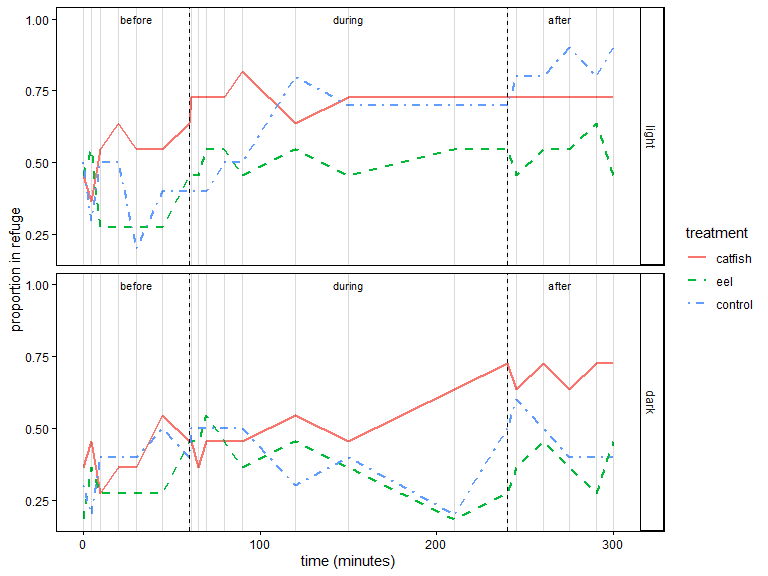

In [ ]:
#| label: fig-refuge-plot
#| include: true
#| fig-cap: "Kōura use of refuge over course of experiment with the three periods (before, during, after), the treatment (catfish; red-solid circle, eel; green-dashed triangle, control; blue-dotdash square), and divided over light regime (combined, dark, light). The points represent the proportion within each period for each treatment."

# calculate the proportions of location for each treatment for each time step
prop_location_time <- koura_long_ref %>%
  filter(!is.na(location), location != "") %>%
  count(treatment, time, light, location = location, name = "n") %>%
  group_by(treatment, time, light) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
         location  = factor(location,  levels = c("refuge","open")),
         light     = factor(light,     levels = c("light", "dark")))

refuge_plot <- prop_location_time %>%
  dplyr::filter(location == "refuge") %>%
  ggplot2::ggplot(aes(time, prop, colour = treatment, group = treatment, linetype = treatment)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  geom_vline(xintercept = c(0, 5, 10, 20, 30, 45, 60, 61, 65, 70, 80, 90, 120, 150, 210, 240, 245, 260, 275, 290, 300), alpha = .15) +
  annotate("text", x = 30,  y = 1, label = "before", size = 3) +
  annotate("text", x = 150, y = 1, label = "during", size = 3) +
  annotate("text", x = 270, y = 1, label = "after",  size = 3) +
  scale_linetype_manual(values = c("solid", "dashed", "dotdash")) +
  facet_grid(light ~ ., scales = "free_x") +
  labs(x = "time (minutes)", y = "proportion in refuge", colour = "treatment", linetype = "treatment")

ggsave(file.path(out_dir, "refuge_plot.png"), refuge_plot, width = 8, height = 5, dpi = 300)

## Refuge stats

                          model      AIC      BIC    logLik delta_AIC
m7_no_re               m7_no_re 688.3155 711.1179 -337.1577      0.00
m1_main                 m1_main 689.1152 715.1752 -336.5576      0.80
m8_tank_round     m8_tank_round 690.1033 719.4207 -336.0516      1.79
m4_light_period m4_light_period 691.7566 724.3316 -335.8783      3.44
m3_trt_light       m3_trt_light 692.8617 725.4367 -336.4309      4.55
m2_trt_period     m2_trt_period 694.7197 733.8096 -335.3598      6.40
m5_twoway             m5_twoway 701.1463 753.2663 -334.5732     12.83
m9_null                 m9_null 703.3633 713.1358 -348.6816     15.05
m6_full                 m6_full 707.9106 773.0605 -333.9553     19.60

 Family: betabinomial  ( logit )
Formula:          
cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period
Data: round_summary

      AIC       BIC    logLik -2*log(L)  df.resid 
    688.3     711.1    -337.2     674.3       185 


Dispersion parameter for betabinomial family (): 0.631 

Conditional model:
                 Estimate Std. Error z value Pr(>|z|)   
(Intercept)       -0.0581     0.2821  -0.206  0.83682   
treatmentcatfish   0.4237     0.2917   1.452  0.14642   
treatmenteel      -0.4270     0.2941  -1.452  0.14656   
lightdark         -0.6542     0.2390  -2.737  0.00619 **
periodduring       0.5298     0.2816   1.881  0.05995 . 
periodafter        0.9125     0.3001   3.040  0.00236 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

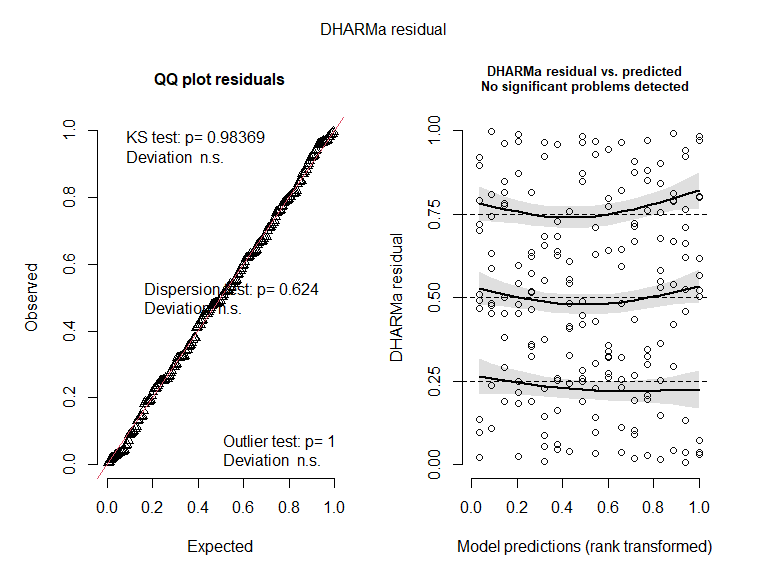

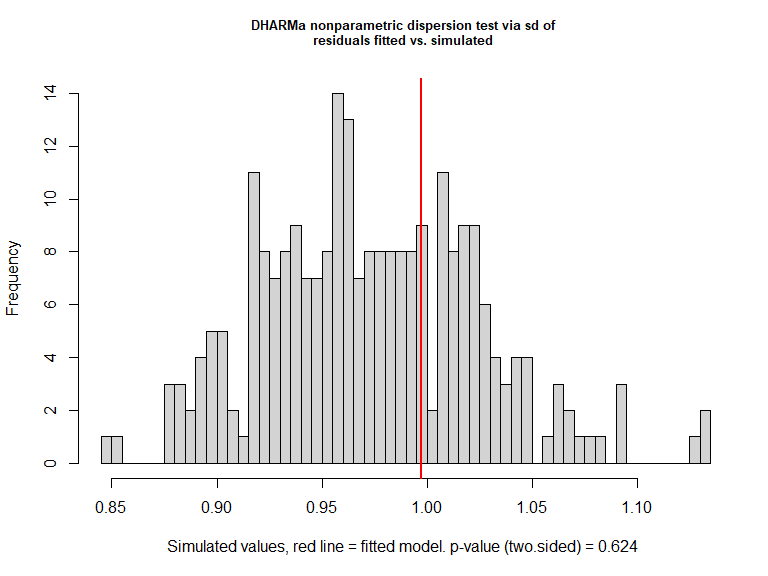


    DHARMa nonparametric dispersion test via sd of residuals fitted vs.
    simulated

data:  simulationOutput
dispersion = 1.0247, p-value = 0.624
alternative hypothesis: two.sided

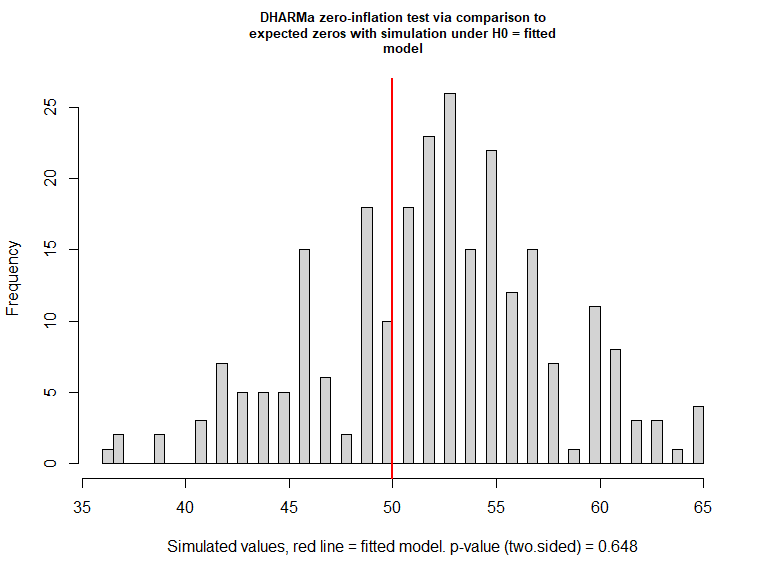


    DHARMa zero-inflation test via comparison to expected zeros with
    simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 0.95668, p-value = 0.648
alternative hypothesis: two.sided

In [ ]:
#| label: refuge-stats
#| include: false

koura_stat <- koura_long_ref %>%
  select(treatment, exp_id, round, tank, time, period, light, location, koura_id, size_mm1, weight_g1) %>%
  mutate(
    location = factor(location, levels = c("refuge", "open")),
    period   = factor(period,   levels = c("before", "during", "after")),
    tank     = factor(tank))

round_summary <- koura_stat %>%
  group_by(treatment, exp_id, round, tank, light, period, koura_id, size_mm1, weight_g1) %>%
  summarise(n_total  = n(),n_refuge = sum(location == "refuge"), .groups  = "drop") %>%
  mutate(treatment = relevel(factor(treatment), ref = "control"),
    light = relevel(factor(light), ref = "light"),   
    before = relevel(factor(period), ref = "before"))

# Model selection
models_bb <- list(
  # --- Fixed effects structure (with tank as random, the defensible RE) ---
  m1_main = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | tank),
    data = round_summary, family = betabinomial),
  m2_trt_period = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * period + light + (1 | tank),
    data = round_summary, family = betabinomial),
  m3_trt_light = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light + period + (1 | tank),
    data = round_summary, family = betabinomial),
  m4_light_period = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m5_twoway = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light + treatment * period + light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m6_full = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  # --- Random effects structure (main effects fixed, vary RE) ---
  m7_no_re = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period,
    data = round_summary, family = betabinomial),
  m8_tank_round = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | tank) + (1 | round),
    data = round_summary, family = betabinomial),
  # --- Null model for baseline comparison ---
  m9_null = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ 1 + (1 | tank),
    data = round_summary, family = betabinomial)
)


comparison_bb <- data.frame(
  model  = names(models_bb),
  AIC    = sapply(models_bb, AIC),
  BIC    = sapply(models_bb, BIC),
  logLik = sapply(models_bb, \(m) as.numeric(logLik(m)))) |>
  arrange(AIC) |>
  mutate(delta_AIC = round(AIC - min(AIC), 2))

print(comparison_bb)

### Fixed effect tbl

In [ ]:
#| label: tbl-s2-fixed-effects
#| include: true
#| tbl-cap: "Fixed effects of the beta-binomial GLMM for kōura refuge use."

# Save fixed effects table 
fixed_bb <- as.data.frame(summary(m_final)$coefficients$cond) %>%
  rownames_to_column("term") %>%
  mutate(across(where(is.numeric), round, 3))

write.csv(fixed_bb, file.path(out_dir, "table_bb_fixed_effects.csv"), row.names = FALSE)

knitr::kable(fixed_bb, col.names = c("Term", "Estimate", "Std. Error", "z value", "p value"))

  Term                 Estimate   Std. Error   z value   p value
  ------------------ ---------- ------------ --------- ---------
  (Intercept)            -0.058        0.282    -0.206     0.837
  treatmentcatfish        0.424        0.292     1.452     0.146
  treatmenteel           -0.427        0.294    -1.452     0.147
  lightdark              -0.654        0.239    -2.737     0.006
  periodduring            0.530        0.282     1.881     0.060
  periodafter             0.912        0.300     3.040     0.002


### Emmeans tbl

In [ ]:
#| label: tbl-s3-emmeans
#| include: true
#| tbl-cap: "Pairwise contrasts from the beta-binomial GLMM for kōura refuge use. Odds ratios and p-values are shown for treatment, light condition, and period comparisons. P-values are Tukey-adjusted for multiple comparisons within each factor."

# Marginal means and pairwise contrasts 
emm_treatment <- as.data.frame(pairs(emmeans(m_final, ~ treatment, type = "response"))) %>% mutate(factor = "treatment")
emm_light     <- as.data.frame(pairs(emmeans(m_final, ~ light,     type = "response"))) %>% mutate(factor = "light")
emm_period    <- as.data.frame(pairs(emmeans(m_final, ~ period,    type = "response"))) %>% mutate(factor = "period")

emmeans_bb <- bind_rows(emm_treatment, emm_light, emm_period) %>%
  mutate(across(where(is.numeric), round, 3))


# Get emmeans for each factor
emm_treatment <- emmeans(m_final, ~ treatment, type = "response")
emm_light     <- emmeans(m_final, ~ light, type = "response")
emm_period    <- emmeans(m_final, ~ period, type = "response")

# Compute CLDs for each factor
cld_treatment <- multcomp::cld(emm_treatment, Letters = letters, adjust = "sidak")
cld_light     <- multcomp::cld(emm_light, Letters = letters, adjust = "sidak")
cld_period    <- multcomp::cld(emm_period, Letters = letters, adjust = "sidak")

# Add factor labels and rename x variable for plotting
cld_treatment <- cld_treatment %>% mutate(factor = "treatment", x = treatment)
cld_light     <- cld_light %>% mutate(factor = "light", x = light)
cld_period    <- cld_period %>% mutate(factor = "period", x = period)

# Combine all CLDs
cld_all <- bind_rows(cld_treatment, cld_light, cld_period) %>%
  mutate(factor = factor(factor, levels = c("treatment", "light", "period")),
         x = factor(x, levels = c("catfish", "eel", "control", "dark", "light", "before", "during", "after")))

# extract specific p-values for inline reporting
p_catfish_eel     <- emmeans_bb %>% filter(contrast == "catfish / eel")     %>% pull(p.value)
p_catfish_control <- emmeans_bb %>% filter(contrast == "catfish / control") %>% pull(p.value)
p_control_eel     <- emmeans_bb %>% filter(contrast == "control / eel")     %>% pull(p.value)
p_before_after    <- emmeans_bb %>% filter(contrast == "before / after")    %>% pull(p.value)
p_before_during   <- emmeans_bb %>% filter(contrast == "before / during")   %>% pull(p.value)
p_during_after    <- emmeans_bb %>% filter(contrast == "during / after")    %>% pull(p.value)
p_dark_light      <- emmeans_bb %>% filter(contrast == "dark / light")      %>% pull(p.value)

write.csv(emmeans_bb,  file.path(out_dir, "table_bb_emmeans.csv"), row.names = FALSE)

knitr::kable(emmeans_bb,col.names = c("Contrast", "Odds ratio", "SE", "df", "Null", "z value", "p value", "Factor"), digits = 3)

  ---------------------------------------------------------------------------------
  Contrast            Odds ratio      SE    df   Null  z value  p value Factor
  ------------------ ----------- ------- ----- ------ -------- -------- -----------
  control / catfish        0.655   0.191   Inf      1   -1.452    0.314 treatment

  control / eel            1.533   0.451   Inf      1    1.452    0.314 treatment

  catfish / eel            2.341   0.681   Inf      1    2.924    0.010 treatment

  light / dark             1.924   0.460   Inf      1    2.737    0.006 light

  before / during          0.589   0.166   Inf      1   -1.881    0.144 period

  before / after           0.402   0.121   Inf      1   -3.040    0.007 period

  during / after           0.682   0.205   Inf      1   -1.276    0.409 period
  ---------------------------------------------------------------------------------


## Emmeans plot

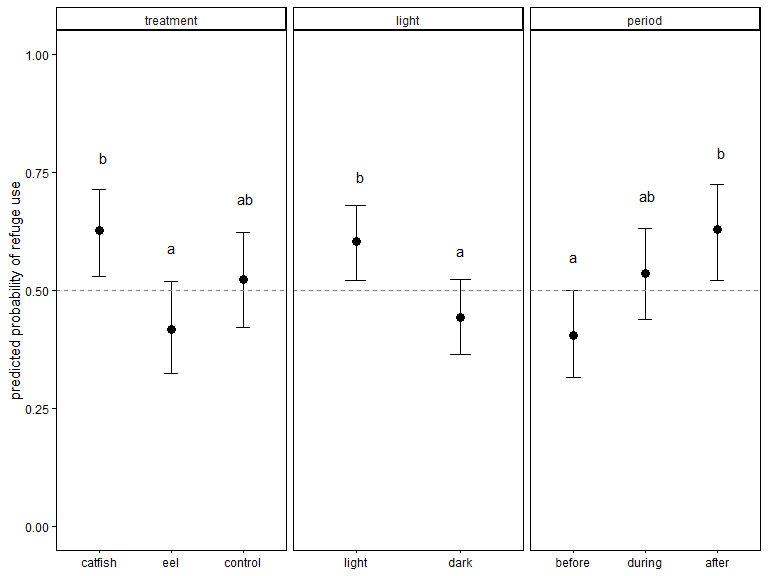

In [ ]:
#| label: fig-emmeans-plot
#| include: true
#| fig-cap: "Predicted marginal probabilities of refuge use from the beta-binomial GLMM for each level of treatment, light condition, and experimental period. Points represent model-estimated marginal means averaged over other factors, with 95% confidence intervals shown as error bars. Different letters (a, b) indicate statistically significant differences between groups within each factor based on multiple comparison-adjusted pairwise comparisons. The dashed line at 0.5 marks the threshold where kōura spend half their time in refuge."

# Make plot
# get predicted probabilities (not contrasts) for plotting
emm_treat_pred  <- as.data.frame(emmeans(m_final, ~ treatment, type = "response"))
emm_light_pred  <- as.data.frame(emmeans(m_final, ~ light,     type = "response"))
emm_period_pred <- as.data.frame(emmeans(m_final, ~ period,    type = "response"))


# add factor label and rename x variable
emm_treat_pred  <- emm_treat_pred  %>% mutate(factor = "treatment", x = treatment)
emm_light_pred  <- emm_light_pred  %>% mutate(factor = "light",     x = light)
emm_period_pred <- emm_period_pred %>% mutate(factor = "period",    x = period)


emm_all <- bind_rows(emm_treat_pred, emm_light_pred, emm_period_pred) %>%
  mutate(factor = factor(factor, levels = c("treatment", "light", "period")),
         x = factor(x, levels = c("catfish", "eel", "control", "light", "dark", "before", "during", "after")))

emmeans_plot <- ggplot(emm_all, aes(x = x, y = prob, ymin = asymp.LCL, ymax = asymp.UCL)) +
  geom_point(size = 3) +
  geom_errorbar(width = 0.2) +
  geom_text(data = cld_all, aes(x = x, y = asymp.UCL + 0.05, label = .group), inherit.aes = FALSE) +
  facet_wrap(~ factor, scales = "free_x") +
  scale_y_continuous("predicted probability of refuge use", limits = c(0, 1)) +
  scale_x_discrete(NULL) +
  geom_hline(yintercept = 0.5, linetype = "dashed", colour = "grey50")

ggsave(file.path(out_dir, "emmeans_plot.png"), emmeans_plot, width = 5, height = 3, dpi = 300)

emmeans_plot

## Summary table of koura used

In [ ]:
#| label: tbl-koura
#| include: false
#| tbl-cap: "Summary of kōura used in experiments"

grps <- list(c("treatment","light"), "treatment", "light", character(0))
tags <- c("treatment+light","treatment","light","overall")

summary_animals <- Map(function(g, tag)
  df_NCE_raw %>%
    group_by(across(all_of(g))) %>%
    summarise(n_trials = n(), mean_size = mean(size_mm1, na.rm=TRUE), sd_size = sd(size_mm1, na.rm=TRUE), min_size  = min(size_mm1, na.rm = TRUE), max_size = max(size_mm1, na.rm = TRUE), mean_weight = mean(weight_g1, na.rm=TRUE), sd_weight = sd(weight_g1,       na.rm=TRUE),min_weight = min(weight_g1, na.rm = TRUE),
      max_weight = max(weight_g1, na.rm = TRUE),.groups="drop") %>%
    mutate(grouping=tag) %>%
    { if(!"treatment"%in%g) mutate(., treatment="All") else . } %>%
    { if(!"light"%in%g)     mutate(., light="All")     else . },
  grps, tags) %>%
  bind_rows() %>%
  select(grouping, treatment, light, everything()) %>%
  arrange(factor(grouping, levels=tags), treatment, light)

# need to make into nice table
knitr::kable(summary_animals, digits = 2)

  ------------------------------------------------------------------------------------------------------------------------------------------------
  grouping          treatment   light     n_trials   mean_size   sd_size   min_size   max_size   mean_weight   sd_weight   min_weight   max_weight
  ----------------- ----------- ------- ---------- ----------- --------- ---------- ---------- ------------- ----------- ------------ ------------
  treatment+light   catfish     dark            11       25.99      2.97      21.46      30.28         11.64        4.06            6           19

  treatment+light   catfish     light           11       26.45      1.53      23.84      28.47         11.45        2.91            8           17

  treatment+light   control     dark            10       25.93      4.76      18.35      32.95         11.60        6.79            3           23

  treatment+light   control     light           10       26.17      1.86      23.71      29.97         11.50        2.88            9           17

  treatment+light   eel         dark            11       25.16      4.37      18.35      30.95         12.00        5.62            3           21

  treatment+light   eel         light           11       26.66      2.12      23.58      29.49         12.00        2.86            8           17

  treatment         catfish     All             22       26.22      2.32      21.46      30.28         11.55        3.45            6           19

  treatment         control     All             20       26.05      3.52      18.35      32.95         11.55        5.07            3           23

  treatment         eel         All             22       25.91      3.44      18.35      30.95         12.00        4.35            3           21

  light             All         dark            32       25.68      3.97      18.35      32.95         11.75        5.38            3           23

  light             All         light           32       26.44      1.81      23.58      29.97         11.66        2.80            8           17

  overall           All         All             64       26.06      3.08      18.35      32.95         11.70        4.25            3           23
  ------------------------------------------------------------------------------------------------------------------------------------------------


## Plots individual koura

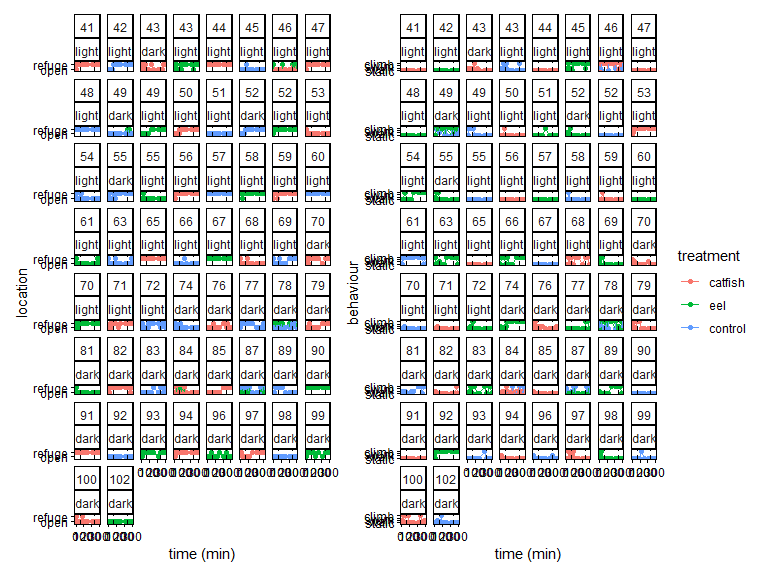

In [ ]:
#| label: fig-koura
#| include: false
#| fig-cap: "your caption"

loc_order <- c("ref_back","ref_open","ref_next","wall","floor","barrier")
beh_order <- c("static","walk","swim","climb")

koura_location_time <- koura_long %>%
  mutate(location = factor(location, levels = loc_order), treatment = factor(treatment, levels = c("catfish", "eel", "control")))


koura_behaviour_time <- koura_long %>%
  mutate(behaviour = factor(behaviour, levels = beh_order), treatment = factor(treatment, levels = c("catfish", "eel", "control")))

# --- Plots ---
p_loc_time <- ggplot(koura_long_ref, aes(time, location, col = treatment)) +
  geom_point() +  
  geom_line(aes(group = koura_id)) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ light) +
  labs(x = "time (min)", y = "location")+
  theme(legend.position = "none")

p_beh_time <- ggplot(koura_behaviour_time, aes(time, behaviour, col = treatment)) +
  geom_point() +
  geom_line(aes(group = koura_id))+
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ light) +
  labs(x = "time (min)", y = "behaviour") 

# --- Combine ---
koura_time_plot <- p_loc_time + p_beh_time
koura_time_plot

## koura length refuge use

# A tibble: 64 × 6
   exp_id treatment size_mm1 total_obs refuge_obs prop_refuge
    <int> <chr>        <dbl>     <int>      <int>       <dbl>
 1      1 catfish       27.2        21         20      0.952 
 2      2 eel           26.0        21         15      0.714 
 3      3 control       23.7        21          9      0.429 
 4      4 catfish       24.7        21         21      1     
 5      5 eel           29.5        21          1      0.0476
 6      6 control       24.6        21          8      0.381 
 7      7 catfish       23.8        21         20      0.952 
 8      8 eel           24.2        21         21      1     
 9      9 control       25.8        21          9      0.429 
10     10 catfish       28.5        21         14      0.667 
# ℹ 54 more rows


    Spearman's rank correlation rho

data:  cor_catfish$size_mm1 and cor_catfish$prop_refuge
S = 1929.1, p-value = 0.6927
alternative hypothesis: true rho is not equal to 0
sample estimates:
        rho 
-0.08928623 


    Spearman's rank correlation rho

data:  cor_eel$size_mm1 and cor_eel$prop_refuge
S = 1606, p-value = 0.6801
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
0.09315701 


    Spearman's rank correlation rho

data:  cor_control$size_mm1 and cor_control$prop_refuge
S = 1113.9, p-value = 0.4936
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.1625111 

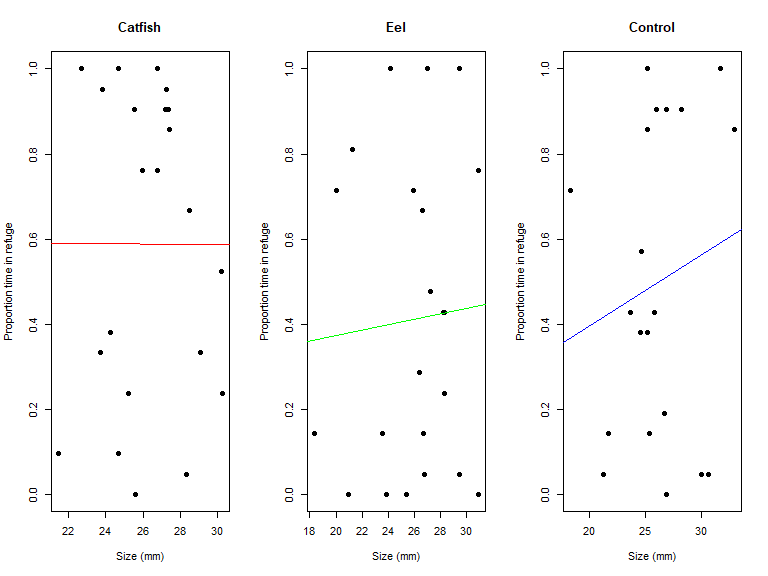

In [ ]:
#| label: Koura-refuge-use
#| include: false

# Calculate proportion of time each koura spent in refuge (overall)
refuge_by_koura <- koura_long_ref %>%
  group_by(exp_id , treatment, size_mm1) %>%
  summarise(
    total_obs = n(),
    refuge_obs = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = refuge_obs / total_obs,
    .groups = "drop"
  )

# Check what you have
print(refuge_by_koura)

## Koura before behaviour

In [ ]:
#| label: Koura-before-behaviour
#| include: false

df_before <- koura_long_ref %>% 
  filter(period =="before") %>%
  filter(!is.na(location), location != "") %>%
  count(exp_id, treatment, light, location = location, name = "n") %>%
  group_by(exp_id) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
    location  = factor(location,  levels = c("refuge","open"))) %>%
  filter(location == "refuge")

# Coefficient of Variation (CV)
before_cv_ref <- df_before %>%
  group_by(light) %>%
  summarise(cv = sd(prop) / mean(prop) * 100)

#leveneTest(prop ~ light, data = df_before)
#fligner.test(prop ~ light, data = df_before)


time_compare <- koura_long_ref %>%
  filter(time == 5 | time == 60) %>%
  filter(!is.na(location), location != "") %>%
  group_by(time, location) %>%
  summarise(n = n(), .groups = "drop") %>%
  pivot_wider(names_from = location, values_from = n, values_fill = 0)

# contingency table
cont_table <- time_compare %>%
  select(refuge, open) %>%
  as.matrix()

rownames(cont_table) <- c("time_5", "time_60")

# chi-square test
#chisq.test(cont_table)

# Fisher's exact (better for small counts)
#fisher.test(cont_table)

## Repeated measurements

In [ ]:
#| label: repeated-measurements
#| include: false
#| fig-cap: "your caption"

repeated_ids <- unique(df_NCE_raw$koura_id[duplicated(df_NCE_raw$koura_id)])

df_repeated <- koura_long_ref %>% 
  filter(koura_id %in% repeated_ids) %>%
  filter(!is.na(location), location != "") %>%
  count(koura_id, treatment, exp_id, location = location, name = "n") %>%
  group_by(koura_id, exp_id) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
    location  = factor(location,  levels = c("refuge","open")))

# Collapse to one score per individual per trial - e.g. prop time refuge
refuge_score <- df_repeated %>%
  filter(location == "refuge") %>%
  group_by(koura_id, exp_id, treatment) %>%
  summarise(prop_refuge = mean(prop), .groups = "drop")

plot_repeated_time <- 
  koura_long_ref %>%
  filter(koura_id %in% repeated_ids) %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")))%>%
  ggplot(aes(x = time, y = location, col = treatment)) +
  geom_point() +  
  geom_line(aes(group = exp_id)) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_grid(koura_id  ~ date) +
  labs(x = "time (min)", y = "location")

plot_repeated_time

# Feeding experiment

## Feeding table

In [ ]:
#| label: tbl-feeding
#| include: true
#| tbl-cap: "Mean feeding rate per gram body weight by treatment and starvation day."

df_feeding <- df_Feeding_raw %>%
  mutate(pellets_eaten_24h = total_fed - left_after_24h,
    pellets_per_g = pellets_eaten_24h / weight_g,
    koura_id = as.factor(koura_id),
    treatment = as.factor(treatment),
    day_starve = as.factor(day_starve),
    treatment = factor(treatment, levels = c("catfish", "eel", "control")))


# summary table
feeding_summary <- df_feeding %>%
  group_by(treatment, day_starve) %>%
  summarise(
    mean = round(mean(pellets_per_g, na.rm = TRUE), 3),
    se   = round(sd(pellets_per_g, na.rm = TRUE) / sqrt(n()), 3),
    .groups = "drop"
  )

# helpers for inline use
get_mean <- function(trt, starve) {
  feeding_summary %>% filter(treatment == trt, day_starve == starve) %>% pull(mean)
}

get_se <- function(trt, starve) {
  feeding_summary %>% filter(treatment == trt, day_starve == starve) %>% pull(se)
}

get_mean_se <- function(trt, starve) {
  row <- feeding_summary %>% filter(treatment == trt, day_starve == starve)
  paste0(row$mean, " ± ", row$se)
}

knitr::kable(feeding_summary, col.names = c("Treatment", "Days starved", "Mean (pellets/g)", "SE"))

  Treatment   Days starved     Mean (pellets/g)      SE
  ----------- -------------- ------------------ -------
  catfish     0                           0.027   0.018
  catfish     3                           0.235   0.055
  catfish     4                           0.059   0.017
  eel         0                           0.031   0.023
  eel         3                           0.105   0.037
  eel         4                           0.052   0.028
  control     0                           0.018   0.018
  control     3                           0.134   0.046
  control     4                           0.148   0.050


## Feeding plot

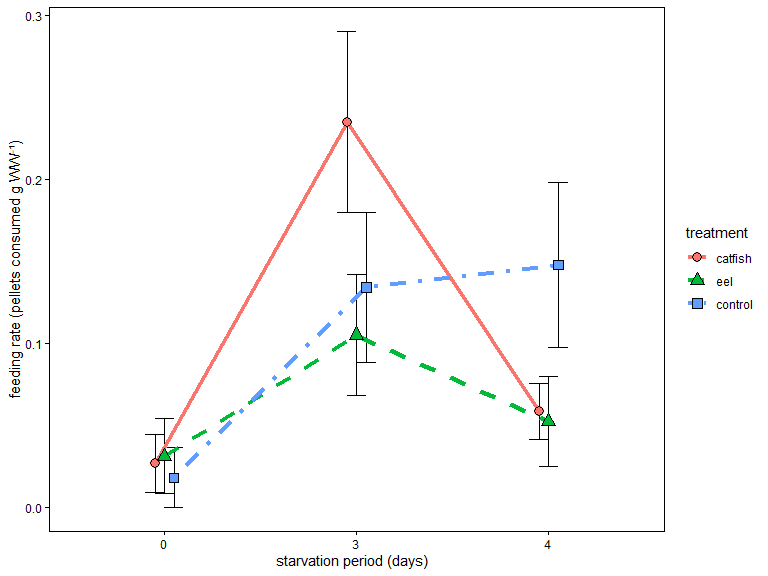

In [ ]:
#| label: fig-feeding-plot
#| include: true
#| fig-cap: "Mean kōura feeding rate (pellets consumed per gram body weight ± SE) across predator treatments (catfish, eel, control) and starvation periods (0, 3, and 4 days). Points represent treatment means and error bars show standard error."

feeding_plot <- ggplot(df_feeding, aes(day_starve, pellets_per_g, col = treatment, group = treatment)) +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.3, linewidth = 0.5, col = "black", position = position_dodge(0.15)) +
  stat_summary(fun = mean, geom = "line", aes(linetype = treatment), linewidth = 1.5, position = position_dodge(0.15)) +
  stat_summary(fun = mean, geom = "point", aes(fill = treatment, shape = treatment), stroke = 1, col = "black", size = 3, position = position_dodge(0.15)) +
  scale_linetype_manual(values = c("solid", "dashed", "dotdash")) +
  scale_shape_manual(values = c(21, 24, 22)) +
  #facet_grid(treatment ~.) +
  labs(x = "starvation period (days)  ", y = "feeding rate (pellets consumed g WW⁻¹)", col = "treatment", linetype = "treatment", shape = "treatment", fill = "treatment")

ggsave(file.path(out_dir, "feeding_plot.png"), feeding_plot, width = 8, height = 5, dpi = 300)

feeding_plot

## Feeding stats

   model       AIC       BIC   logLik delta_AIC
m1    m1 -92.78035 -74.06834 56.39018      0.00
m6    m6 -92.04488 -84.56008 50.02244      0.74
m2    m2 -90.84779 -79.62058 51.42389      1.93
m5    m5 -77.96702 -70.48221 42.98351     14.81
m4    m4 -60.77347 -47.67506 37.38674     32.01
m3    m3 -47.65574 -27.07253 34.82787     45.12

Anova Table (Type III tests)

Response: pellets_per_g
                       Sum Sq Df F value    Pr(>F)    
(Intercept)          0.004401  1  0.6401 0.4285109    
treatment            0.000446  2  0.0325 0.9680855    
day_starve           0.131605  2  9.5709 0.0004152 ***
treatment:day_starve 0.061643  4  2.2415 0.0821411 .  
Residuals            0.268134 39                      
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

 treatment day_starve emmean     SE df lower.CL upper.CL
 catfish   0          0.0271 0.0339 39  -0.0414   0.0956
 eel       0          0.0312 0.0371 39  -0.0438   0.1062
 control   0          0.0182 0.0371 39  -0.0568   0.0932
 catfish   3          0.2351 0.0371 39   0.1601   0.3101
 eel       3          0.1052 0.0339 39   0.0367   0.1737
 control   3          0.1342 0.0371 39   0.0592   0.2092
 catfish   4          0.0587 0.0371 39  -0.0163   0.1337
 eel       4          0.0524 0.0371 39  -0.0226   0.1274
 control   4          0.1477 0.0339 39   0.0792   0.2162

Confidence level used: 0.95 


    Shapiro-Wilk normality test

data:  residuals(lm_feed)
W = 0.97279, p-value = 0.324

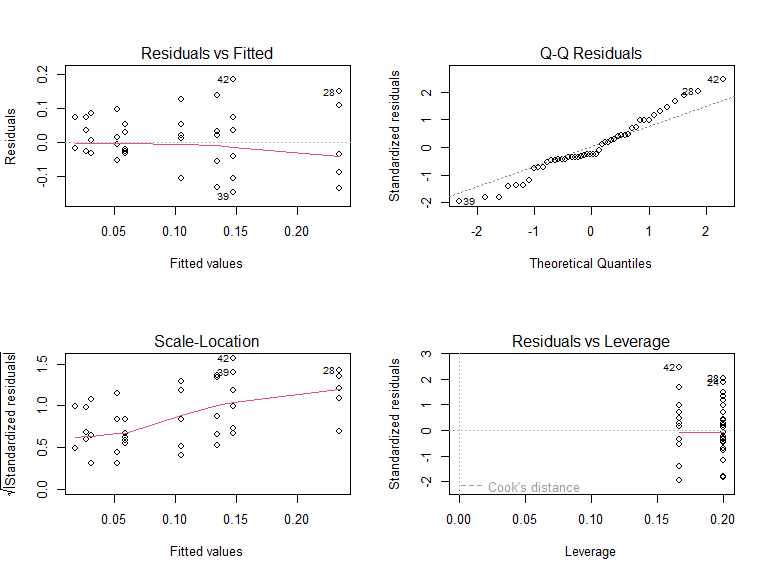

day_starve = 0:
 contrast          estimate     SE df t.ratio p.value
 catfish - eel     -0.00414 0.0502 39  -0.082  0.9963
 catfish - control  0.00890 0.0502 39   0.177  0.9828
 eel - control      0.01304 0.0524 39   0.249  0.9665

day_starve = 3:
 contrast          estimate     SE df t.ratio p.value
 catfish - eel      0.12987 0.0502 39   2.587  0.0354
 catfish - control  0.10087 0.0524 39   1.923  0.1456
 eel - control     -0.02900 0.0502 39  -0.578  0.8329

day_starve = 4:
 contrast          estimate     SE df t.ratio p.value
 catfish - eel      0.00628 0.0524 39   0.120  0.9921
 catfish - control -0.08899 0.0502 39  -1.772  0.1921
 eel - control     -0.09527 0.0502 39  -1.898  0.1529

P value adjustment: tukey method for comparing a family of 3 estimates 

            Df   Sum Sq   Mean Sq F value Pr(>F)
treatment    2 0.000446 0.0002232   0.109  0.897
Residuals   13 0.026563 0.0020433               

            Df Sum Sq Mean Sq F value Pr(>F)
treatment    2 0.0491 0.02455   2.207   0.15
Residuals   13 0.1446 0.01112               

            Df  Sum Sq  Mean Sq F value Pr(>F)
treatment    2 0.03193 0.015965    2.14  0.157
Residuals   13 0.09699 0.007461               

 contrast          estimate     SE df t.ratio p.value
 catfish - eel     -0.00414 0.0274 13  -0.151  0.9875
 catfish - control  0.00890 0.0274 13   0.325  0.9436
 eel - control      0.01304 0.0286 13   0.456  0.8926

P value adjustment: tukey method for comparing a family of 3 estimates 

...


    Shapiro-Wilk normality test

data:  residuals(lm_day4)
W = 0.97557, p-value = 0.9188


    Kruskal-Wallis rank sum test

data:  pellets_per_g by treatment
Kruskal-Wallis chi-squared = 0.43478, df = 2, p-value = 0.8046


    Kruskal-Wallis rank sum test

data:  pellets_per_g by treatment
Kruskal-Wallis chi-squared = 2.568, df = 2, p-value = 0.2769


    Kruskal-Wallis rank sum test

data:  pellets_per_g by treatment
Kruskal-Wallis chi-squared = 2.3595, df = 2, p-value = 0.3074

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 2.3595, df = 2, p-value = 0.31

                   Dunn's Pairwise Comparison of x by group                   
                                 (Bonferroni)                                 
Col Mean-│
Row Mean │    catfish    control
─────────┼──────────────────────
 control │  -1.194448
         │     0.3485 
         │
     eel │   0.199852   1.403187
         │     1.0000     0.2408 

α = 0.05
Reject Ho if p ≤ α/2, where p = Pr(Z ≥ |z|)

In [ ]:
#| label: feeding-stats
#| include: false

# Model selection
feeding_models <- list(
  m1 = lm(pellets_per_g ~ treatment * day_starve, data = df_feeding),
  m2 = lm(pellets_per_g ~ treatment + day_starve, data = df_feeding),
  m3 = lmer(pellets_per_g ~ treatment * day_starve + (1 | exp_tank ), data = df_feeding),
  m4 = lmer(pellets_per_g ~ treatment + day_starve + (1 | exp_tank ), data = df_feeding),
  m5 = lm(pellets_per_g ~ treatment, data = df_feeding),
  m6 = lm(pellets_per_g ~ day_starve, data = df_feeding))

comparison_feeding_models <- data.frame(
  model  = names(feeding_models),
  AIC    = sapply(feeding_models, AIC),
  BIC    = sapply(feeding_models, BIC),
  logLik = sapply(feeding_models, \(m) as.numeric(logLik(m)))) |>
  arrange(AIC) |>
  mutate(delta_AIC = round(AIC - min(AIC), 2))

print(comparison_feeding_models)

### feeding anova tbl

In [ ]:
#| label: tbl-s4-feeding-ano
#| include: true
#| tbl-cap: "Type III ANOVA table for the linear model of kōura feeding rate (pellets consumed per gram body weight). Treatment, starvation period, and their interaction were included as fixed effects."

as.data.frame(anova_feed) %>%
  rownames_to_column("term") %>%
  mutate(across(where(is.numeric), round, 3)) %>%
  knitr::kable(col.names = c("Term", "Sum Sq", "Df", "F value", "p value"))

  Term                     Sum Sq   Df   F value   p value
  ---------------------- -------- ---- --------- ---------
  (Intercept)               0.004    1     0.640     0.429
  treatment                 0.000    2     0.032     0.968
  day_starve                0.132    2     9.571     0.000
  treatment:day_starve      0.062    4     2.241     0.082
  Residuals                 0.268   39        NA        NA
